In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [3]:
# 1. Load the dataset
df = pd.read_csv('gtco_loan_data.csv')

In [4]:
# Drop unique identifier which isn't useful for clustering
df_model = df.drop(columns=['customer_id'])

In [5]:
# 2. Define Features
# Separate numerical and categorical columns for specific preprocessing
num_cols = ['age', 'income_monthly', 'employment_years', 'existing_loans', 
            'account_balance', 'num_products', 'transaction_count', 'account_age_months']
cat_cols = ['region', 'account_type', 'education_level']

In [6]:
# 3. Build Preprocessing Pipeline
# Numerical: Fill missing values with mean, then standardize (scale)
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])
# Categorical: Convert to One-Hot encoded vectors
cat_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ])

In [7]:
# 4. Prepare the Data
X = preprocessor.fit_transform(df_model)

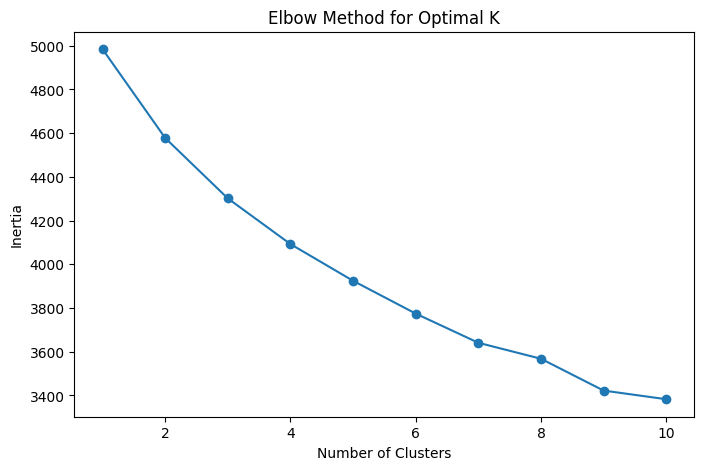

In [8]:
# 5. Elbow Method to find the optimal number of clusters (K)
inertia = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.savefig('elbow_plot.png')

In [9]:
# 6. Apply K-Means
# Based on the plot, pick the 'elbow' point (e.g., k=3)
optimal_k = 3 
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

In [10]:
# 7. Save results
df['cluster'] = clusters
df.to_csv('gtco_loan_data_clustered.csv', index=False)

print("Segmentation complete. Data saved to 'gtco_loan_data_clustered.csv'.")

Segmentation complete. Data saved to 'gtco_loan_data_clustered.csv'.


C:\Users\DELL-PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matplotlib\colors.py:2243: UserWarning: Warning: converting a masked element to nan.
  dtype = np.min_scalar_type(value)
C:\Users\DELL-PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matplotlib\colors.py:2250: UserWarning: Warning: converting a masked element to nan.
  data = np.asarray(value)
C:\Users\DELL-PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matplotlib\ticker.py:563: UserWarning: Warning: converting a masked element to nan.
  else fmt % arg)


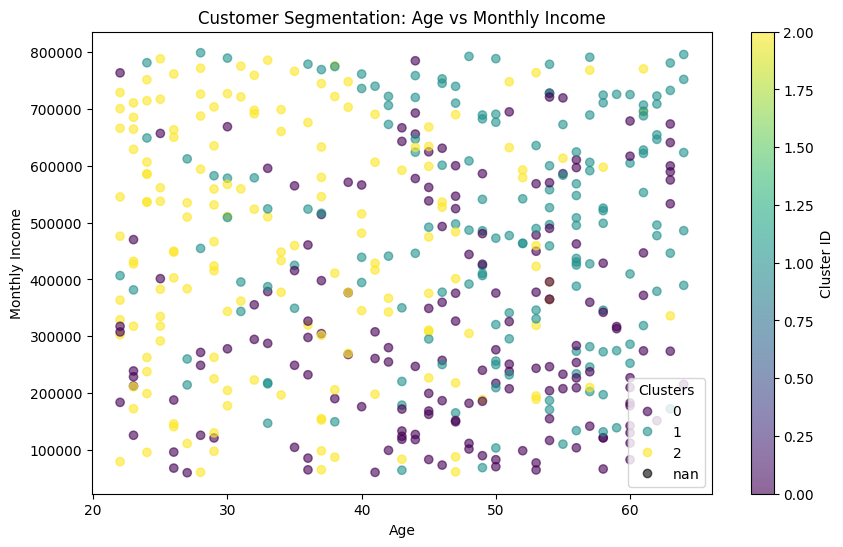

In [11]:
import matplotlib.pyplot as plt

# Load the clustered data
df_clustered = pd.read_csv('gtco_loan_data_clustered.csv')

# Create the scatter plot
plt.figure(figsize=(10, 6))

# Use scatter plot: x-axis = Age, y-axis = Monthly Income
# 'c=df_clustered["cluster"]' assigns the color based on the cluster number
scatter = plt.scatter(df_clustered['age'], df_clustered['income_monthly'], 
                      c=df_clustered['cluster'], cmap='viridis', alpha=0.6)

# Add labels and title
plt.title('Customer Segmentation: Age vs Monthly Income')
plt.xlabel('Age')
plt.ylabel('Monthly Income')

# Add a legend
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.colorbar(scatter, label='Cluster ID')

# Save and display
plt.savefig('cluster_mapping.png')
plt.show()

In [12]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# 'X' is the preprocessed numerical matrix (from the previous pipeline)
# 'clusters' are the labels assigned by your KMeans model
silhouette_avg = silhouette_score(X, clusters)
calinski_harabasz = calinski_harabasz_score(X, clusters)
davies_bouldin = davies_bouldin_score(X, clusters)

print(f"Silhouette Score: {silhouette_avg:.3f}")
print(f"Calinski-Harabasz Index: {calinski_harabasz:.3f}")
print(f"Davies-Bouldin Index: {davies_bouldin:.3f}")

Silhouette Score: 0.072
Calinski-Harabasz Index: 39.429
Davies-Bouldin Index: 2.902
